In [1]:
#//--//--//--//--//--//--//--//--//LIBRERÍAS//--//--//--//--//--//--//--//--//
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
#//--//--//--//--//--//--//--//--//CONFIGURACIÓN DE HARDWARE//--//--//--//--//--//--//--//--//

"""
    Configura TensorFlow para usar múltiples hilos y mejorar rendimiento en CPU.
    Si tiene GPU, omitir estas líneas.
"""
tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(8)

In [3]:
#//--//--//--//--//--//--//--//--//FUNCIÓN PARA CARGAR DATOS//--//--//--//--//--//--//--//--//
"""
    Carga el archivo Excel que contiene las tasas de cambio, usando la hoja indicada.
"""
def cargar_datos(file_path, sheet_name="Tasasdecambio"):
    
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    return df

In [4]:
#//--//--//--//--//--//--//--//--//FUNCIONES AUXILIARES//--//--//--//--//--//--//--//--//

def construir_dataset(series, m, tau):
    """
        Construye el conjunto de datos con embedding m y retardo tau.
        Devuelve X (entradas), y (salidas) para entrenamiento.
    """
    X, y = [], []
    for i in range(len(series) - m * tau):
        X.append(series[i:i + m * tau:tau])
        y.append(series[i + m * tau])
    return np.array(X).reshape(-1, m, 1), np.array(y)

def calcular_bic(y_true, y_pred, k, Nm):
    """
        Calcula el BIC (Bayesian Information Criterion) para evaluar la calidad del modelo.
        Penaliza la complejidad del modelo con base en k (número de neuronas).
    """
    mse = np.mean((y_true - y_pred) ** 2)
    return 0.5 * (1 + np.log(2 * np.pi) + 2 * np.log(mse) + (k * np.log(Nm)) / Nm)

In [5]:
#//--//--//--//--//--//--//--//--//MODELO Y ENTRENAMIENTO//--//--//--//--//--//--//--//--//

def crear_modelo_rnn(k, m):
    """
        Crea el modelo secuencial RNN simple con una capa SimpleRNN y una capa de salida.
    """
    model = Sequential([
        tf.keras.Input(shape=(m, 1)),
        SimpleRNN(k, activation='tanh',
                  kernel_initializer='glorot_uniform',
                  recurrent_initializer='orthogonal'),
        Dense(1)
    ])
    return model

def entrenar_modelo_rnn(model, X_train, y_train):
    """
        Entrena el modelo con early stopping monitoreando la pérdida.
    """
    callback = tf.keras.callbacks.EarlyStopping(
        monitor='loss', patience=5, min_delta=1e-4)

    model.compile(loss='mse', optimizer='adam')
    model.fit(X_train, y_train, epochs=100,
              batch_size=32, callbacks=[callback], verbose=0)
    return model

In [6]:
#//--//--//--//--//--//--//--//--//CÁLCULO DE EXPONENTES DE LYAPUNOV//--//--//--//--//--//--//--//--//

def calcular_exponente_lyapunov(modelo, X):
    """
        Estima el exponente de Lyapunov a partir de la red entrenada, 
        usando la derivada de la función de activación y el Jacobiano de la RNN.
    """
    W, U, b = modelo.layers[0].get_weights()
    k = W.shape[1]  # número de neuronas ocultas
    lyap_exp = []
    
    X_seq = np.squeeze(X, axis=-1)  # remueve la última dimensión

    for seq in X_seq:
        J = np.eye(k)
        h = np.zeros(k)
        for x in seq:
            h_input = np.dot(W.T, x) + np.dot(U.T, h) + b
            h_new = np.tanh(h_input)
            psi_prime = 1 - h_new**2  # derivada de tanh
            J = psi_prime[:, None] * (np.dot(U.T, J) + W.T)
            h = h_new
        eigvals = np.linalg.eigvals(J)
        lyap_exp.append(np.log(np.abs(eigvals.max())))

    return np.mean(lyap_exp)

In [7]:
#//--//--//--//--//--//--//--//--//EVALUACIÓN DE CONFIGURACIONES//--//--//--//--//--//--//--//--//

def evaluar_configuracion(m, tau, k, serie_scaled):
    """
        Evalúa una combinación de hiperparámetros (m, tau, k) con validación cruzada temporal.
        Devuelve el modelo entrenado con su BIC medio.
    """
    try:
        X, y = construir_dataset(serie_scaled, m, tau)
        if len(X) < 20:
            return None

        tscv = TimeSeriesSplit(n_splits=2)
        bic_values = []

        for train_index, val_index in tscv.split(X):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            model = crear_modelo_rnn(k, m)
            model = entrenar_modelo_rnn(model, X_train, y_train)
            y_pred = model.predict(X_val, verbose=0).flatten()
            bic = calcular_bic(y_val, y_pred, k, len(y_val))
            bic_values.append(bic)

        return {
            'm': m, 'tau': tau, 'k': k,
            'bic': np.mean(bic_values),
            'model': model
        }
    except:
        return None

In [8]:
#//--//--//--//--//--//--//--//--//ANÁLISIS POR PAÍS//--//--//--//--//--//--//--//--//

def analizar_pais(pais, segmentos, df, progress_bar=None):
    """
        Evalúa todas las configuraciones y segmentos de un país dado.
        Retorna una lista de resultados con el mejor modelo por segmento.
    """
    resultados_pais = []
    for fecha_ini, fecha_fin in segmentos:
        serie_segmento = df.loc[fecha_ini:fecha_fin, pais].dropna().values
        if len(serie_segmento) < 50:
            if progress_bar:
                progress_bar.update(1)
            continue

        scaler = MinMaxScaler()
        serie_scaled = scaler.fit_transform(serie_segmento.reshape(-1, 1)).flatten()

        configs = [(m, tau, k) for m in range(1, 4) for tau in range(1, 3) for k in range(1, 4)]

        resultados_paralelos = Parallel(n_jobs=-1, prefer="threads")(
            delayed(evaluar_configuracion)(m, tau, k, serie_scaled)
            for m, tau, k in configs
        )

        resultados_validos = [r for r in resultados_paralelos if r is not None]
        if not resultados_validos:
            if progress_bar:
                progress_bar.update(1)
            continue

        mejor_resultado = min(resultados_validos, key=lambda x: x['bic'])

        X_total, _ = construir_dataset(serie_scaled, mejor_resultado['m'], mejor_resultado['tau'])
        lyap_exp = calcular_exponente_lyapunov(mejor_resultado['model'], X_total)

        resultados_pais.append({
            "País": pais,
            "Inicio": fecha_ini,
            "Fin": fecha_fin,
            "m": mejor_resultado['m'],
            "tau": mejor_resultado['tau'],
            "k": mejor_resultado['k'],
            "BIC": mejor_resultado['bic'],
            "Lyapunov": lyap_exp
        })

        if progress_bar:
            progress_bar.update(1)

    return resultados_pais

Cargando datos...
Procesando países...


Progreso general:   0%|                                                                         | 0/12 [00:00<?, ?it/s]

Progreso general: 100%|███████████████████████████████████████████████████████████████| 12/12 [21:24<00:00, 107.04s/it]



Resultados completos:
   País      Inicio         Fin  m  tau  k       BIC  Lyapunov
0   CLP  2010-01-04  2011-12-30  1    1  1 -1.699555 -0.300860
1   CLP  2012-01-03  2013-12-30  1    1  3 -1.800299 -0.012930
2   CLP  2014-01-02  2015-12-31  2    2  1 -1.935725  0.154363
3   COP  2010-01-04  2011-12-30  3    2  3 -1.702291 -0.216817
4   COP  2012-01-03  2013-12-30  3    1  1 -1.262003 -0.632920
5   COP  2014-01-02  2015-12-31  1    2  2 -1.409546  0.105961
6   MXN  2010-01-04  2011-12-30  2    2  2 -1.089619 -0.930081
7   MXN  2012-01-03  2013-12-30  1    1  2 -1.394933  0.578857
8   MXN  2014-01-02  2015-12-31  2    1  2 -1.585509 -5.175055
9   PEN  2010-01-04  2011-12-30  3    1  2 -0.853431  0.082124
10  PEN  2012-01-03  2013-12-30  1    1  2 -0.870150 -0.010441
11  PEN  2014-01-02  2015-12-31  1    1  2 -1.036865 -0.006085


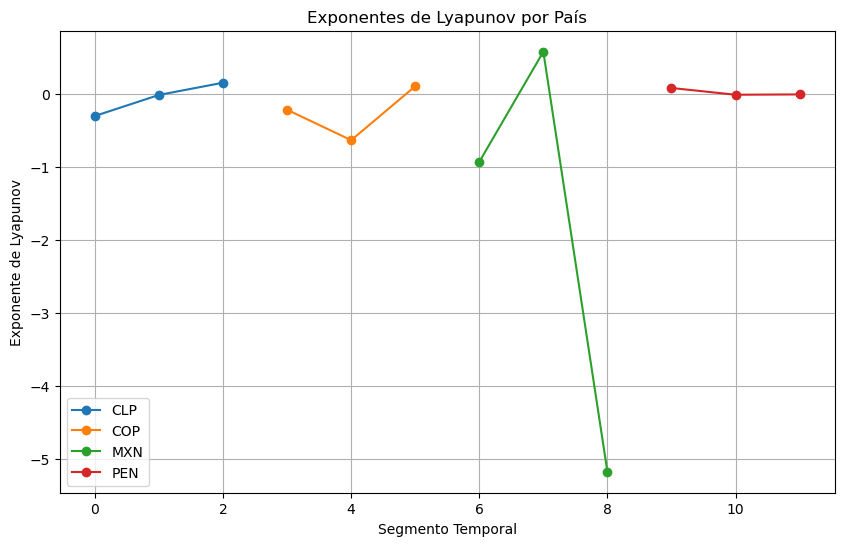

Resultados guardados en 'resultados_lyapunov.csv'


In [9]:
#//--//--//--//--//--//--//--//--//PARAMETROS//--//--//--//--//--//--//--//--//

def main():
    file_path = "C:/Users/DELL/Documents/Konrad Lorenz/IV SEMESTRE/Tasas_de_Cambio.xlsx"
    segmentos = [("2010-01-04", "2011-12-30"),
                 ("2012-01-03", "2013-12-30"),
                 ("2014-01-02", "2015-12-31")]
    paises = ["CLP", "COP", "MXN", "PEN"]

    print("Cargando datos...")
    df = cargar_datos(file_path)

    print("Procesando países...")
    resultados_totales = []

    with tqdm(total=len(paises)*len(segmentos), desc="Progreso general") as pbar:
        for pais in paises:
            resultados_pais = analizar_pais(pais, segmentos, df, progress_bar=pbar)
            resultados_totales.extend(resultados_pais)

    resultados_df = pd.DataFrame(resultados_totales)
    print("\nResultados completos:")
    print(resultados_df)

    plt.figure(figsize=(10, 6))
    for pais in paises:
        pais_df = resultados_df[resultados_df
        ['País'] == pais]
        if not pais_df.empty:
            plt.plot(pais_df['Lyapunov'], label=pais, marker='o')
    plt.title("Exponentes de Lyapunov por País")
    plt.xlabel("Segmento Temporal")
    plt.ylabel("Exponente de Lyapunov")
    plt.legend()
    plt.grid(True)
    plt.savefig('comparacion_lyapunov.png')
    plt.show()

    resultados_df.to_csv("resultados_lyapunov.csv", index=False)
    print("Resultados guardados en 'resultados_lyapunov.csv'")

if __name__ == "__main__":
    main()